# DSM Reliability Main Code

This code is the one to be run. This is the file where the inputs are set and the iterations run
based on the user's desire. The inputs define the parameters of the DSM and simulation, as well as
outputing the reliability graphs. This file uses the functions set on Reliability.py.

## Inputs

- Mission_time: How long does the DSM mission lasts, in years.
- iteration: string that asks whether the user wants to try another DSM configuration
- graph_labels: array that compiles the configuration parameters entered to be lated used as the graph's label.
- EPS_redundancy: Boolean variable, defines the existence or absence in redundancy in EPS subsystem.
- Phase_Deployment: Boolean variable, defines the use of phased deployment as mission strategy.
- DSM_min_amount: Minimal amount of elements the DSM must have operative.
- DSM_initial_amount: Initial amount of elements launched in the first batch, backups included.
- relaunch_rate: Amount of months between launches of new batches to the DSM
- DSM_relaunch_amount: Amount of satellites to be thrown per relaunch.
- cont: variable used in the iteration of a final graph.


## Outputs
- Time_years: Output of the function Reliability. An array of equally spaced time in years.
- R_DSM: Array of numbers output of the Reliability function that gives the reliability of the DSM configuration.
- R_simulation: Matrix that compiles all of the simulations of the different DSM configurations tested.
- 2-D Graph compiling the DSM configurations entered by the user'''

In [4]:
from matplotlib import pyplot as plt
from Reliability import no_phase
from Reliability import Reliability

In [5]:
# Defining empty arrays and strings.
R_simulation = []
iteration = ''
graph_labels = []

# User interface, where the program asks you to enter inputs to feed the function

while iteration != 'n' or iteration != 'N':

    EPS_redundancy = ''
    Phase_Deployment = ''
# Asks you the existence of redundancy in EPS
    while EPS_redundancy != 'y' or EPS_redundancy != 'Y' or EPS_redundancy != 'n' or EPS_redundancy != 'N':
        EPS_redundancy = input('Is there a redundancy in EPS? (y/n): ')
        if EPS_redundancy == 'y' or EPS_redundancy == 'Y':
            EPS_redundancy = True
            break
        elif EPS_redundancy == 'n' or EPS_redundancy == 'N':
            EPS_redundancy = False
            break
        else:
            print('ERROR. Please try again.') # ask you the initial size of the DSM and its minimum amount of operability
    print('EPS Redundancy: ', EPS_redundancy)
    DSM_min_amount = int(input('What is the minimal amount of CubeSats the DSM needs so it is still considered operative? Enter an integer: '))
    print('Minimum amount of CubeSat for the DSM to be operative set to ' + str(DSM_min_amount) + ' CubeSats')
    DSM_initial_amount = int(input('What is the amount of CubeSats the DSM begins on the first batch? Enter an integer: '))
    print('Initial amount of CubeSats started in the DSM: ' + str(DSM_initial_amount) + ' CubeSats')

    Mission_time = int(input('How much time does the mission last? Enter an integer: '))
    print('The mission will last: ' + str(Mission_time) + ' years') #ask how long is the mission
    
# Ask you whether the launch strategy is a phased deployment. If true it calls function Reliability and input other parameters, else it calls no_phase
    while Phase_Deployment != 'y' or Phase_Deployment != 'Y' or Phase_Deployment != 'n' or Phase_Deployment != 'N':
        Phase_Deployment = input('Phased Deployment? (y/n): ')
        
        if Phase_Deployment != 'y' and Phase_Deployment != 'Y':

            Time_years, R_DSM = no_phase(EPS_redundancy, DSM_min_amount, DSM_initial_amount, Mission_time)
            relaunch_rate = 0
            DSM_relaunch_amount = 0
            break
        else:

            DSM_relaunch_amount = int(input('How many CubeSats are to be relaunched? Enter and integer: '))
            relaunch_rate = int(input('Every how many months do you want to deploy satellites again? Enter an integer: '))
            print(str (DSM_relaunch_amount) + ' Satellites will be launched every ' + str(relaunch_rate) + ' months')
            Time_years, R_DSM = Reliability(EPS_redundancy, DSM_min_amount, DSM_initial_amount, DSM_relaunch_amount, relaunch_rate, Mission_time)
            break
        #Asks if you want to try another configuration. It will be added to the graph for comparison.
    iteration = input('Simulation Finished! Do you want to try another DSM setting? (y/n): ')
    if iteration == 'n' or iteration == 'N':
        R_simulation.append(R_DSM)
        graph_labels.append('EPS_redundancy: ' + str(EPS_redundancy) + ', minimum: ' + str(DSM_min_amount) + ', initial: ' + str(DSM_initial_amount) + ', relaunch: ' + str(DSM_relaunch_amount) + ', rate: ' + str(relaunch_rate))
        break
    else:
        print('----------------------------------------------------------')
        R_simulation.append(R_DSM)
        graph_labels.append('EPS_redundancy: ' + str(EPS_redundancy) + ', minimum: ' + str(DSM_min_amount) + ', initial: ' + str(DSM_initial_amount) + ', '
                                                                                                                'relaunch:'
                                                                                                                ' ' +
                     str(DSM_relaunch_amount) + ',rate: ' + str(relaunch_rate))
        continue


EPS Redundancy:  False
Minimum amount of CubeSat for the DSM to be operative set to 5 CubeSats
Initial amount of CubeSats started in the DSM: 6 CubeSats
The mission will last: 2 years
1 Satellites will be launched every 4 months


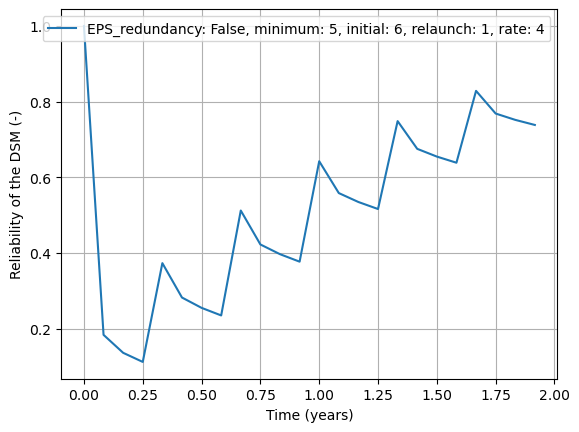

In [6]:
plt.figure(1)

for cont in range(len(R_simulation)):
    plt.plot(Time_years / 12, R_simulation[cont], label=graph_labels[cont])

plt.xlabel('Time (years)')
plt.ylabel('Reliability of the DSM (-)')
plt.legend()
plt.grid(True)
plt.show()